# Test heat equation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import HeatEqn as HE

## Exact solution

From https://web.stanford.edu/class/math220b/handouts/heateqn.pdf

$$
\frac{\partial u}{\partial t} = \alpha \nabla^2 u
$$
$$
u(\mathbf{x}, 0) = \phi(\mathbf{x})
$$

$$
u(\mathbf{x}, t) = \frac{1}{(4\alpha\pi t)^{n/2}} \int \int \phi (\mathbf{y}) \exp\left( -\frac{|\mathbf{x}-\mathbf{y}|^2}{4\alpha t}  \right) d^n \mathbf{y}
$$

For
$$
\phi(\mathbf{y}) = \exp\left( -\beta |\mathbf{y}|^2 \right)
$$

$$
u(\mathbf{x}, t) = \frac{1}{4\alpha t \left(\beta + \frac{1}{4\alpha t} \right)} \exp \left( - \frac{\beta |\mathbf{x}|^2 }{4\alpha t \beta +1} \right)
$$

In [2]:
def uexact(y,z,t, alpha, beta):
    x2 = y**2 + z**2
    return np.exp(-x2*beta/(4*alpha*t*beta+1.0))/(4.0*alpha*t*beta + 1.0)

## Numerical solution

In [3]:
Ny=401
Nz=401
yvec = np.linspace(-4,4,Ny)
zvec = np.linspace(-3,3,Nz)
dy   = np.mean(np.diff(yvec))
dz   = np.mean(np.diff(zvec))
print(dy)
print(dz)

0.02
0.015


In [4]:
alpha = 0.25
x0 = 0.0
x1 = 2.0
dx = 0.05
xvec = np.arange(x0, x1 +1e-10, dx)
#print(xvec)

# Set boundary conditions
ylo = {'type':'dirichlet', 'value':0.0}
yhi = {'type':'dirichlet', 'value':0.0}
zlo = {'type':'dirichlet', 'value':0.0}
zhi = {'type':'dirichlet', 'value':0.0}

In [5]:
ym, zm = np.meshgrid(yvec, zvec)
beta = 10
Uinit  = np.zeros((Ny, Nz))
for i, y in enumerate(yvec):
    for j, z in enumerate(zvec):
        Uinit[i,j] = np.exp(-beta*(y**2 + z**2))
#Uinit  = np.exp(-5*(ym**2 + zm**2))
print(Uinit.shape)

(401, 401)


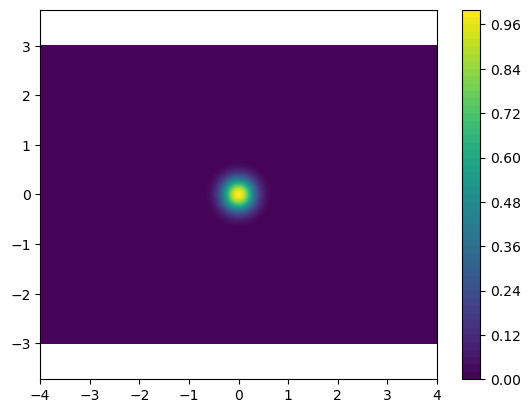

In [6]:
plt.contourf(ym, zm, Uinit.transpose(), levels=np.linspace(0,1,51))
plt.axis('equal')
plt.colorbar()

In [7]:
#u1 = HE.advanceU(Uinit, dx, dy, dz, alpha, ylo, yhi, zlo, zhi)
uSol = HE.marchHeatEqn(Uinit, xvec, dy, dz, alpha, ylo, yhi, zlo, zhi, verbose=True)

[1/40] x = 0.05
[2/40] x = 0.1
[3/40] x = 0.15000000000000002
[4/40] x = 0.2
[5/40] x = 0.25
[6/40] x = 0.30000000000000004
[7/40] x = 0.35000000000000003
[8/40] x = 0.4
[9/40] x = 0.45
[10/40] x = 0.5
[11/40] x = 0.55
[12/40] x = 0.6000000000000001
[13/40] x = 0.65
[14/40] x = 0.7000000000000001
[15/40] x = 0.75
[16/40] x = 0.8
[17/40] x = 0.8500000000000001
[18/40] x = 0.9
[19/40] x = 0.9500000000000001
[20/40] x = 1.0
[21/40] x = 1.05
[22/40] x = 1.1
[23/40] x = 1.1500000000000001
[24/40] x = 1.2000000000000002
[25/40] x = 1.25
[26/40] x = 1.3
[27/40] x = 1.35
[28/40] x = 1.4000000000000001
[29/40] x = 1.4500000000000002
[30/40] x = 1.5
[31/40] x = 1.55
[32/40] x = 1.6
[33/40] x = 1.6500000000000001
[34/40] x = 1.7000000000000002
[35/40] x = 1.75
[36/40] x = 1.8
[37/40] x = 1.85
[38/40] x = 1.9000000000000001
[39/40] x = 1.9500000000000002
[40/40] x = 2.0


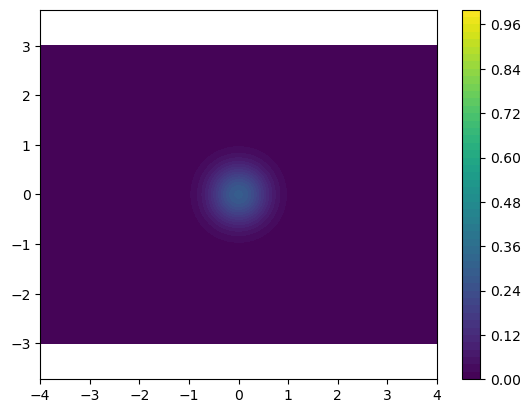

In [8]:
plt.contourf(ym, zm, uSol[5].transpose(), levels=np.linspace(0,1,51))
plt.axis('equal')
plt.colorbar()

0.0


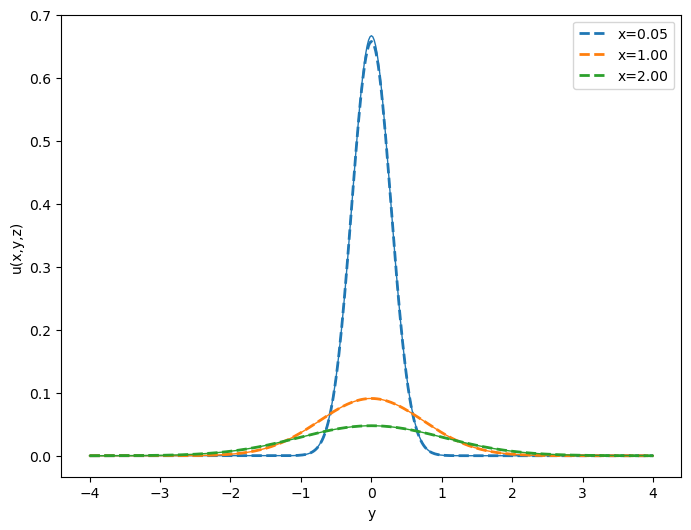

In [9]:
plt.figure(figsize=(8,6))

iz = Nz//2
zcut = zvec[iz]
print(zcut)
for ix in [1,-21, -1]:
    t = xvec[ix]
    plt.plot(yvec,uSol[ix][:,iz], '--', lw=2, label='x=%0.2f'%t)
    ue = uexact(yvec,zcut,t, alpha, beta)
    plt.plot(yvec,ue,'-', lw=1, color=plt.gca().lines[-1].get_color())
    
    
plt.xlabel('y')
plt.ylabel('u(x,y,z)')
plt.legend()